In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('HR-Employee-Attrition.csv')

### Data Exploration

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
display(df.describe())

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Checking for missing values.

In [ ]:
display(df.isnull().sum()[df.isnull().sum() > 0])

,0


Let's analyze the distribution of the target variable: `Attrition`.

Attrition
No     1233
Yes     237
Name: count, dtype: int64


/tmp/ipykernel_12707/1166109311.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette='viridis')


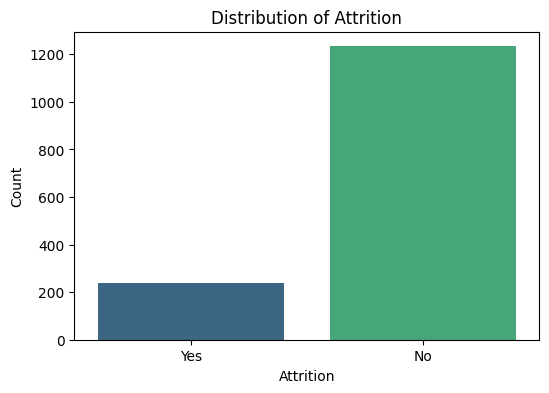

In [ ]:
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette='viridis')
plt.title('Distribution of Attrition')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

In [ ]:
### Data Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras

First, we'll convert the 'Attrition' target variable to numerical (0 or 1).

In [ ]:
label_encoder = LabelEncoder()
df['Attrition_Encoded'] = label_encoder.fit_transform(df['Attrition'])

X = df.drop(['Attrition', 'Attrition_Encoded'], axis=1)
y = df['Attrition_Encoded']

print("Original Attrition values:", df['Attrition'].unique())
print("Encoded Attrition values:", df['Attrition_Encoded'].unique())

Original Attrition values: ['Yes' 'No']
Encoded Attrition values: [1 0]


Next, we'll identify categorical and numerical features for encoding and scaling.

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical columns: {list(categorical_cols)}")
print(f"Numerical columns: {list(numerical_cols)}")

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
Numerical columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Apply one-hot encoding to categorical features and standardize numerical features.

In [ ]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded[numerical_cols]), columns=numerical_cols, index=X_encoded.index)

X_processed = pd.concat([X_encoded.drop(columns=numerical_cols), X_scaled], axis=1)

print("Shape of processed data:", X_processed.shape)
display(X_processed.head())

Shape of processed data: (1470, 47)


,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,False,True,False,True,True,False,False,False,False,False,...,-1.584178,0.0,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834
1,True,False,True,False,True,False,False,False,False,True,...,1.191438,0.0,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541
2,False,True,True,False,False,False,False,True,False,True,...,-0.658973,0.0,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935
3,True,False,True,False,True,False,False,False,False,False,...,0.266233,0.0,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935
4,False,True,True,False,False,False,True,False,False,True,...,1.191438,0.0,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227


### Data Splitting and Class Imbalance Handling (SMOTE)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train before SMOTE:", X_train.shape)
print("Shape of y_train before SMOTE:", y_train.shape)
print("Attrition distribution in y_train before SMOTE:\n", y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nShape of X_train after SMOTE:", X_train_res.shape)
print("Shape of y_train after SMOTE:", y_train_res.shape)
print("Attrition distribution in y_train after SMOTE:\n", y_train_res.value_counts())

Shape of X_train before SMOTE: (1176, 47)
Shape of y_train before SMOTE: (1176,)
Attrition distribution in y_train before SMOTE:
 Attrition_Encoded
0    986
1    190
Name: count, dtype: int64

Shape of X_train after SMOTE: (1972, 47)
Shape of y_train after SMOTE: (1972,)
Attrition distribution in y_train after SMOTE:
 Attrition_Encoded
0    986
1    986
Name: count, dtype: int64


In [ ]:
### Build Deep Neural Network (ANN) Model

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_res.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,513 (64.50 KB)

 Trainable params: 16,513 (64.50 KB)

 Non-trainable params: 0 (0.00 B)

### Compile and Train the Model with Early Stopping

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train_res, y_train_res,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stopping],
                    verbose=1)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6417 - loss: 0.6417 - val_accuracy: 0.5671 - val_loss: 0.7123
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7476 - loss: 0.5286 - val_accuracy: 0.7063 - val_loss: 0.5842
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7964 - loss: 0.4535 - val_accuracy: 0.7696 - val_loss: 0.4947
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8364 - loss: 0.3884 - val_accuracy: 0.8810 - val_loss: 0.2781
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8529 - loss: 0.3460 - val_accuracy: 0.8987 - val_loss: 0.2178
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8776 - loss: 0.3116 - val_accuracy: 0.8861 - val_loss: 0.2545
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8922 - loss: 0.2774 - val_accuracy: 0.9089 - val_loss: 0.1967
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8909 - loss: 0.2707 - val_accuracy: 0.9367 - 

### Model Evaluation and Prediction

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(conf_matrix, index=['Actual No Attrition', 'Actual Attrition'], columns=['Predicted No Attrition', 'Predicted Attrition']))

print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       247
           1       0.51      0.40      0.45        47

    accuracy                           0.84       294
   macro avg       0.70      0.67      0.68       294
weighted avg       0.83      0.84      0.84       294


Confusion Matrix:


,Predicted No Attrition,Predicted Attrition
Actual No Attrition,229,18
Actual Attrition,28,19



Accuracy Score: 0.8435374149659864


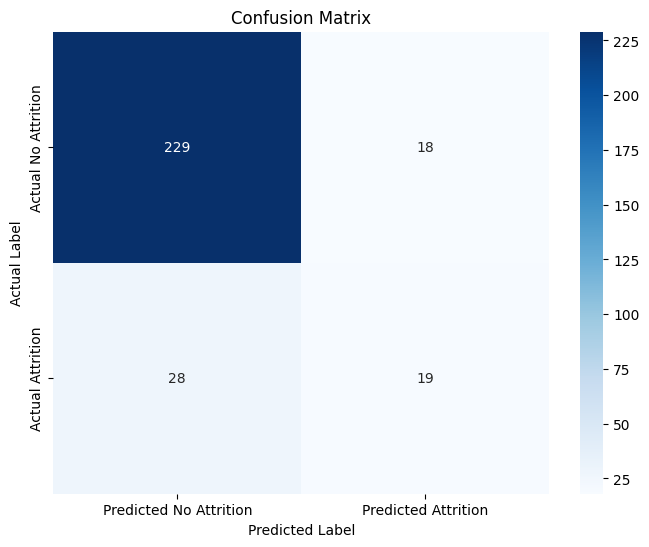

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Attrition', 'Predicted Attrition'],
            yticklabels=['Actual No Attrition', 'Actual Attrition'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### User Input Prediction Function

In [ ]:
def predict_attrition(new_employee_data):
    # Convert new data to a DataFrame, ensuring it's a single row
    new_df = pd.DataFrame([new_employee_data])

    # Replicate preprocessing steps
    # Identify categorical and numerical columns from the original X
    # (assuming categorical_cols and numerical_cols are still defined from earlier steps)
    global categorical_cols, numerical_cols, scaler, X_processed # Access global variables

    # Apply one-hot encoding to categorical features
    new_df_encoded = pd.get_dummies(new_df, columns=categorical_cols, drop_first=True)

    # Align columns with X_processed to handle missing dummy variables
    # Important: Ensure the order and presence of all columns as in X_processed
    final_cols = X_processed.columns
    new_df_aligned = new_df_encoded.reindex(columns=final_cols, fill_value=0)

    # Scale numerical features using the *fitted* scaler
    # Ensure we only scale the numerical part of the aligned dataframe
    # First, separate numerical columns from the aligned dataframe
    new_df_num = new_df_aligned[numerical_cols]
    new_df_cat = new_df_aligned.drop(columns=numerical_cols)

    new_df_scaled_num = pd.DataFrame(scaler.transform(new_df_num), columns=numerical_cols, index=new_df.index)

    # Recombine scaled numerical and one-hot encoded categorical features
    new_data_processed = pd.concat([new_df_cat, new_df_scaled_num], axis=1)

    # Ensure the order of columns is exactly as expected by the model
    new_data_processed = new_data_processed[final_cols]

    # Make prediction
    prediction_proba = model.predict(new_data_processed)[0][0]
    prediction_class = (prediction_proba > 0.5).astype(int)

    # Map back to 'Yes' or 'No'
    attrition_result = label_encoder.inverse_transform([prediction_class])[0]

    return attrition_result, prediction_proba

### Example Usage of the Prediction Function

Let's create a hypothetical employee profile and use our function to predict if they will attrit.

In [ ]:
sample_employee_data = {
    'Age': 35,
    'BusinessTravel': 'Travel_Rarely',
    'DailyRate': 800,
    'Department': 'Research & Development',
    'DistanceFromHome': 5,
    'Education': 3,
    'EducationField': 'Life Sciences',
    'EmployeeCount': 1,
    'EmployeeNumber': 1000,
    'EnvironmentSatisfaction': 3,
    'Gender': 'Male',
    'HourlyRate': 60,
    'JobInvolvement': 3,
    'JobLevel': 2,
    'JobRole': 'Research Scientist',
    'JobSatisfaction': 3,
    'MaritalStatus': 'Married',
    'MonthlyIncome': 4000,
    'MonthlyRate': 15000,
    'NumCompaniesWorked': 2,
    'Over18': 'Y',
    'OverTime': 'No',
    'PercentSalaryHike': 15,
    'PerformanceRating': 3,
    'RelationshipSatisfaction': 3,
    'StandardHours': 80,
    'StockOptionLevel': 1,
    'TotalWorkingYears': 10,
    'TrainingTimesLastYear': 3,
    'WorkLifeBalance': 3,
    'YearsAtCompany': 5,
    'YearsInCurrentRole': 3,
    'YearsSinceLastPromotion': 1,
    'YearsWithCurrManager': 3
}

predicted_attrition, prediction_probability = predict_attrition(sample_employee_data)

print(f"Predicted Attrition: {predicted_attrition}")
print(f"Prediction Probability (for 'Yes'): {prediction_probability:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Attrition: No
Prediction Probability (for 'Yes'): 0.0000


In [ ]:
import pickle

# Save the model
model.save('attrition_model.h5')

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the column names (MOST IMPORTANT)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X_processed.columns), f)

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Sab save ho gaya!")

Sab save ho gaya!


In [ ]:
import pickle
import json

# Architecture alag save karo
model_json = model.to_json()
with open('model_architecture.json', 'w') as f:
    json.dump(model_json, f)

# Weights alag save karo
model.save_weights('model_weights.weights.h5')

# Baaki files
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X_processed.columns), f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Done!")

Done!


In [ ]:
import pickle
import numpy as np

# Weights list of arrays hai, numpy se nahi save hoga
# pickle use karo instead
weights = model.get_weights()
with open('model_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X_processed.columns), f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Done!")

Done!


In [ ]:
import pickle

weights = model.get_weights()
with open('model_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

print("Done!")


Done!


In [ ]:
import pickle
import numpy as np

weights = model.get_weights()
weights_list = [w.tolist() for w in weights]

with open('model_weights_list.pkl', 'wb') as f:
    pickle.dump(weights_list, f)

print("Done!")

Done!


In [ ]:
import pickle
import numpy as np

# Scaler ko manually save karo
scaler_params = {
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist(),
    'var': scaler.var_.tolist(),
    'n_features': scaler.n_features_in_,
    'feature_names': list(numerical_cols)
}

with open('scaler_params.pkl', 'wb') as f:
    pickle.dump(scaler_params, f)

print("Done!")

Done!


In [ ]:
import pickle

with open('model_columns_list.pkl', 'wb') as f:
    pickle.dump(list(X_processed.columns), f)

le_classes = label_encoder.classes_.tolist()
with open('le_classes.pkl', 'wb') as f:
    pickle.dump(le_classes, f)

print("Done!")

Done!
